# Tahap 5 — Model Evaluation

Tahap ini digunakan untuk mengukur performa retrieval dan prediksi solusi.

Notebook ini disesuaikan dengan ketentuan soal:

1. Evaluasi retrieval menggunakan:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
2. Fungsi utama:
   ```python
   eval_retrieval(queries, ground_truth, k)
   ```
3. Tabel metrik per model:
   - `tfidf_cosine`
   - `svm_assisted`
4. Plot bar chart performance.
5. Error analysis/rejection analysis.
6. Output:
   ```text
   data/eval/retrieval_metrics.csv
   data/eval/prediction_metrics.csv
   ```


## 1. Import Library dan Load Data

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CASES_PATH = PROJECT_ROOT / "data" / "processed" / "cases.csv"
QUERIES_PATH = PROJECT_ROOT / "data" / "eval" / "queries.json"
PREDICTIONS_PATH = PROJECT_ROOT / "data" / "results" / "predictions.csv"

EVAL_DIR = PROJECT_ROOT / "data" / "eval"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not CASES_PATH.exists():
    raise FileNotFoundError("cases.csv belum ditemukan. Jalankan Tahap 2 terlebih dahulu.")

if not QUERIES_PATH.exists():
    raise FileNotFoundError("queries.json belum ditemukan. Jalankan Tahap 3 terlebih dahulu.")

df = pd.read_csv(CASES_PATH).fillna("")

with QUERIES_PATH.open("r", encoding="utf-8") as f:
    queries = json.load(f)

print(f"Jumlah kasus : {len(df)}")
print(f"Jumlah query : {len(queries)}")

Jumlah kasus : 48
Jumlah query : 10


## 2. Menyiapkan Teks Retrieval

In [2]:
required_cols = [
    "case_id",
    "ringkasan_fakta",
    "argumen_hukum_utama",
    "pasal",
    "pihak",
    "text_full",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib belum tersedia: {missing_cols}")

optional_cols = []
if "dasar_hukum" in df.columns:
    optional_cols.append("dasar_hukum")

retrieval_cols = ["ringkasan_fakta", "argumen_hukum_utama", "pasal"] + optional_cols + ["pihak"]
df["text_for_retrieval"] = df[retrieval_cols].astype(str).agg(" ".join, axis=1)

print("Kolom retrieval:", retrieval_cols)

Kolom retrieval: ['ringkasan_fakta', 'argumen_hukum_utama', 'pasal', 'pihak']


## 3. TF-IDF dan SVM-assisted

In [3]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=8000,
    ngram_range=(1, 2),
    min_df=1,
)

case_vectors = tfidf_vectorizer.fit_transform(df["text_for_retrieval"])

print("Matriks TF-IDF:", case_vectors.shape)

svm_model = None
svm_vectorizer = None
svm_label_info = "SVM tidak dipakai karena label solusi tidak cukup variasi."

if "solution_label" in df.columns and df["solution_label"].nunique() >= 2:
    if df["solution_label"].value_counts().min() >= 2:
        stratify_col = df["solution_label"]
    else:
        stratify_col = None

    df_train, df_test = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=stratify_col
    )

    label_counts = df_train["solution_label"].astype(str).value_counts()
    usable_labels = label_counts[label_counts >= 2].index.tolist()
    df_svm = df_train[df_train["solution_label"].astype(str).isin(usable_labels)].copy()

    if len(usable_labels) >= 2 and df_svm["solution_label"].nunique() >= 2:
        svm_vectorizer = TfidfVectorizer(
            lowercase=True,
            max_features=5000,
            ngram_range=(1, 2)
        )
        X_train = svm_vectorizer.fit_transform(df_svm["text_for_retrieval"])
        y_train = df_svm["solution_label"].astype(str)

        svm_model = LinearSVC(random_state=42, max_iter=5000)
        svm_model.fit(X_train, y_train)

        svm_label_info = f"SVM aktif. Kelas label solusi: {list(svm_model.classes_)}"

print(svm_label_info)

Matriks TF-IDF: (48, 8000)
SVM aktif. Kelas label solusi: ['mengabulkan_sebagian', 'menolak']


## 4. Fungsi Retrieval

In [4]:
def retrieve(query: str, k: int = 5, method: str = "tfidf_cosine") -> list:
    query = str(query).lower().strip()
    if not query:
        return []

    query_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, case_vectors).flatten()

    predicted_label = None

    if method == "svm_assisted" and svm_model is not None and svm_vectorizer is not None:
        predicted_label = svm_model.predict(svm_vectorizer.transform([query]))[0]
        label_bonus = (df["solution_label"].astype(str).values == predicted_label).astype(float) * 0.05
        scores = scores + label_bonus
    elif method not in ["tfidf_cosine", "svm_assisted"]:
        raise ValueError("method harus 'tfidf_cosine' atau 'svm_assisted'")

    k = min(k, len(df))
    top_idx = np.argsort(scores)[::-1][:k]

    results = []
    for rank, idx in enumerate(top_idx, start=1):
        row = df.iloc[idx]
        results.append({
            "rank": rank,
            "case_id": row["case_id"],
            "no_perkara": row.get("no_perkara", ""),
            "score": round(float(scores[idx]), 6),
            "predicted_label_query": predicted_label,
            "solution_label_case": row.get("solution_label", "lainnya"),
        })

    return results

print("Fungsi retrieve() siap digunakan.")

Fungsi retrieve() siap digunakan.


## 5. Fungsi `eval_retrieval(queries, ground_truth, k)`

In [5]:
def eval_retrieval(queries, ground_truth=None, k: int = 5, method: str = "tfidf_cosine"):
    """Evaluasi retrieval berdasarkan ground-truth case_id.

    Sesuai soal:
    - Loop setiap query.
    - Ambil ground_truth_case_id.
    - Hitung apakah ground_truth_case_id masuk ke top-k hasil retrieval.
    - Hitung Accuracy, Precision, Recall, dan F1-Score menggunakan sklearn.metrics.

    Catatan:
    Query evaluasi berasal dari queries.json. Jika query dibuat dari case base,
    nilai retrieval dapat sangat tinggi karena sistem menemukan kembali case_id sumber query.
    """
    y_true = []
    y_pred = []
    detail_rows = []
    precision_at_k_values = []
    recall_at_k_values = []

    for q in queries:
        query_id = q.get("query_id", "")
        query_text = q.get("query_text", "")
        gt = q.get("ground_truth_case_id", [])

        if isinstance(gt, str):
            gt = [gt]

        retrieved = retrieve(query_text, k=k, method=method)
        retrieved_ids = [r["case_id"] for r in retrieved]

        relevant_retrieved = len(set(retrieved_ids) & set(gt))
        hit = 1 if relevant_retrieved > 0 else 0

        # Semua query memiliki ground-truth positif.
        y_true.append(1)
        y_pred.append(hit)

        precision_at_k = relevant_retrieved / k if k > 0 else 0
        recall_at_k = relevant_retrieved / len(gt) if len(gt) > 0 else 0

        precision_at_k_values.append(precision_at_k)
        recall_at_k_values.append(recall_at_k)

        detail_rows.append({
            "query_id": query_id,
            "method": method,
            "ground_truth_case_id": ", ".join(gt),
            "retrieved_case_ids": ", ".join(retrieved_ids),
            "hit": hit,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "top_1_case_id": retrieved_ids[0] if retrieved_ids else "",
            "top_1_score": retrieved[0]["score"] if retrieved else 0,
        })

    metrics = {
        "method": method,
        "k": k,
        "Accuracy_Hit@K": accuracy_score(y_true, y_pred) if y_true else 0,
        "Precision": precision_score(y_true, y_pred, zero_division=0) if y_true else 0,
        "Recall": recall_score(y_true, y_pred, zero_division=0) if y_true else 0,
        "F1-Score": f1_score(y_true, y_pred, zero_division=0) if y_true else 0,
        "Mean_Precision@K": float(np.mean(precision_at_k_values)) if precision_at_k_values else 0,
        "Mean_Recall@K": float(np.mean(recall_at_k_values)) if recall_at_k_values else 0,
        "Total_Query": len(y_true),
    }

    return metrics, pd.DataFrame(detail_rows)

print("Fungsi eval_retrieval() siap digunakan.")

Fungsi eval_retrieval() siap digunakan.


## 6. Evaluasi Retrieval per Model

In [6]:
all_metrics = []
all_details = []

for method in ["tfidf_cosine", "svm_assisted"]:
    metrics, details_df = eval_retrieval(queries, k=5, method=method)
    all_metrics.append(metrics)
    all_details.append(details_df)

retrieval_metrics_df = pd.DataFrame(all_metrics)
retrieval_details_df = pd.concat(all_details, ignore_index=True)

RETRIEVAL_METRICS_PATH = EVAL_DIR / "retrieval_metrics.csv"
RETRIEVAL_DETAILS_PATH = EVAL_DIR / "retrieval_details.csv"

retrieval_metrics_df.to_csv(RETRIEVAL_METRICS_PATH, index=False)
retrieval_details_df.to_csv(RETRIEVAL_DETAILS_PATH, index=False)

print("Retrieval metrics:")
display(retrieval_metrics_df)

print("Retrieval detail:")
display(retrieval_details_df.head())

Retrieval metrics:


,method,k,Accuracy_Hit@K,Precision,Recall,F1-Score,Mean_Precision@K,Mean_Recall@K,Total_Query
0,tfidf_cosine,5,1.0,1.0,1.0,1.0,0.2,1.0,10
1,svm_assisted,5,1.0,1.0,1.0,1.0,0.2,1.0,10


Retrieval detail:


,query_id,method,ground_truth_case_id,retrieved_case_ids,hit,precision_at_k,recall_at_k,top_1_case_id,top_1_score
0,Q_001,tfidf_cosine,case_029,"case_029, case_020, case_042, case_012, case_030",1,0.2,1.0,case_029,0.522558
1,Q_002,tfidf_cosine,case_042,"case_042, case_012, case_029, case_050, case_030",1,0.2,1.0,case_042,0.509201
2,Q_003,tfidf_cosine,case_028,"case_028, case_027, case_024, case_025, case_018",1,0.2,1.0,case_028,0.448368
3,Q_004,tfidf_cosine,case_046,"case_046, case_017, case_027, case_048, case_025",1,0.2,1.0,case_046,0.412460
4,Q_005,tfidf_cosine,case_026,"case_026, case_048, case_027, case_017, case_033",1,0.2,1.0,case_026,0.236592


## 7. Evaluasi Prediksi Solusi

In [7]:
if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError("data/results/predictions.csv belum ada. Jalankan Tahap 4 terlebih dahulu.")

predictions_df = pd.read_csv(PREDICTIONS_PATH).fillna("")

if "solution_label" in df.columns:
    case_label_map = dict(zip(df["case_id"], df["solution_label"]))
else:
    case_label_map = {case_id: "lainnya" for case_id in df["case_id"]}

predictions_df["true_solution_label"] = (
    predictions_df["ground_truth_case_id"]
    .map(case_label_map)
    .fillna("lainnya")
)

y_true_pred = predictions_df["true_solution_label"].astype(str)
y_pred_pred = predictions_df["predicted_solution_label"].astype(str)

prediction_metrics = {
    "Accuracy": accuracy_score(y_true_pred, y_pred_pred),
    "Precision_Macro": precision_score(y_true_pred, y_pred_pred, average="macro", zero_division=0),
    "Recall_Macro": recall_score(y_true_pred, y_pred_pred, average="macro", zero_division=0),
    "F1_Macro": f1_score(y_true_pred, y_pred_pred, average="macro", zero_division=0),
    "Precision_Weighted": precision_score(y_true_pred, y_pred_pred, average="weighted", zero_division=0),
    "Recall_Weighted": recall_score(y_true_pred, y_pred_pred, average="weighted", zero_division=0),
    "F1_Weighted": f1_score(y_true_pred, y_pred_pred, average="weighted", zero_division=0),
    "Total_Query": len(predictions_df),
}

prediction_metrics_df = pd.DataFrame([prediction_metrics])

PREDICTION_METRICS_PATH = EVAL_DIR / "prediction_metrics.csv"
PREDICTION_DETAILS_PATH = EVAL_DIR / "prediction_details.csv"

prediction_metrics_df.to_csv(PREDICTION_METRICS_PATH, index=False)
predictions_df.to_csv(PREDICTION_DETAILS_PATH, index=False)

print("Prediction metrics:")
display(prediction_metrics_df)

print("Prediction detail:")
display(predictions_df[[
    "query_id",
    "ground_truth_case_id",
    "true_solution_label",
    "predicted_solution_label",
    "selected_case_id",
    "top_5_case_ids"
]].head())

Prediction metrics:


,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted,Total_Query
0,0.6,0.5,0.5,0.5,0.6,0.6,0.6,5


Prediction detail:


,query_id,ground_truth_case_id,true_solution_label,predicted_solution_label,selected_case_id,top_5_case_ids
0,Q_001,case_029,mengabulkan,mengabulkan,case_029,"case_029, case_020, case_042, case_012, case_030"
1,Q_002,case_042,tidak_dapat_diterima,tidak_dapat_diterima,case_042,"case_042, case_012, case_029, case_050, case_030"
2,Q_003,case_028,mengabulkan_sebagian,menolak,case_027,"case_028, case_027, case_024, case_025, case_018"
3,Q_004,case_046,mengabulkan,mengabulkan,case_046,"case_046, case_017, case_027, case_048, case_025"
4,Q_005,case_026,mengabulkan_sebagian,menolak,case_027,"case_026, case_048, case_027, case_017, case_033"


## 8. Visualisasi Performa Retrieval

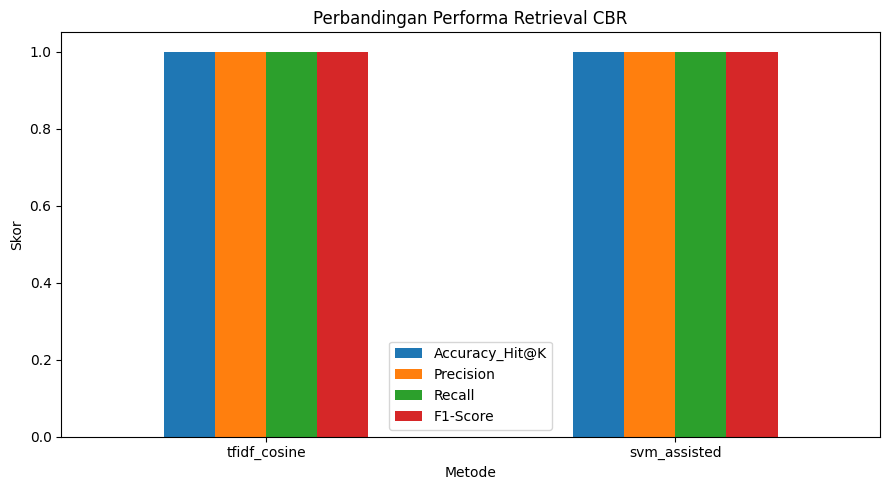

Chart disimpan: /Users/muhammadsenopati/cbr-perdata-waris/data/eval/retrieval_chart.png


In [8]:
plot_df = retrieval_metrics_df.set_index("method")[
    ["Accuracy_Hit@K", "Precision", "Recall", "F1-Score"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Perbandingan Performa Retrieval CBR")
plt.ylabel("Skor")
plt.xlabel("Metode")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower center")
plt.tight_layout()

CHART_PATH = EVAL_DIR / "retrieval_chart.png"
plt.savefig(CHART_PATH, dpi=150)
plt.show()

print("Chart disimpan:", CHART_PATH)

## 9. Error Analysis / Rejection Analysis

In [9]:
baseline_df = retrieval_details_df[retrieval_details_df["method"] == "tfidf_cosine"].copy()
failures_df = baseline_df[baseline_df["hit"] == 0].copy()

RETRIEVAL_FAILURES_PATH = EVAL_DIR / "retrieval_failures.csv"
ERROR_ANALYSIS_PATH = EVAL_DIR / "error_analysis.txt"

failures_df.to_csv(RETRIEVAL_FAILURES_PATH, index=False)

analysis_lines = []
analysis_lines.append("ERROR ANALYSIS / REJECTION ANALYSIS")
analysis_lines.append("=" * 50)
analysis_lines.append(f"Total query evaluasi: {len(queries)}")
analysis_lines.append(f"Total kegagalan retrieval top-5 (baseline tfidf_cosine): {len(failures_df)}")
analysis_lines.append("")
analysis_lines.append("Perbandingan metode retrieval (lihat retrieval_metrics.csv):")

for _, row in retrieval_metrics_df.iterrows():
    analysis_lines.append(
        f"- {row['method']}: "
        f"Accuracy_Hit@5={row['Accuracy_Hit@K']:.3f}, "
        f"Precision={row['Precision']:.3f}, "
        f"Recall={row['Recall']:.3f}, "
        f"F1-Score={row['F1-Score']:.3f}"
    )

analysis_lines.append("")

if len(failures_df) == 0:
    analysis_lines.append("Tidak ada query gagal pada pengujian top-5 saat ini.")
else:
    analysis_lines.append("Daftar query yang gagal ditemukan dalam top-5:")
    for _, row in failures_df.iterrows():
        analysis_lines.append(
            f"- {row['query_id']}: GT={row['ground_truth_case_id']} | Retrieved={row['retrieved_case_ids']}"
        )

analysis_lines.append("")
analysis_lines.append("Rekomendasi perbaikan:")
analysis_lines.append("1. Tambahkan jumlah dokumen putusan agar variasi kasus lebih banyak.")
analysis_lines.append("2. Perbaiki ekstraksi metadata pihak, pasal, dan amar putusan jika banyak bernilai TIDAK DITEMUKAN.")
analysis_lines.append("3. Buat query evaluasi manual yang lebih realistis beserta ground-truth case_id dari dosen/annotator.")
analysis_lines.append("4. Jika label hasil putusan tersedia, latih model klasifikasi SVM/Naive Bayes terhadap label tersebut.")
analysis_lines.append("5. Coba embedding IndoBERT atau Sentence-BERT Indonesia untuk membandingkan dengan TF-IDF.")

with ERROR_ANALYSIS_PATH.open("w", encoding="utf-8") as f:
    f.write("\n".join(analysis_lines))

print("\n".join(analysis_lines))

print("\nOutput Tahap 5:")
print(f"1. Retrieval metrics   : {RETRIEVAL_METRICS_PATH}")
print(f"2. Prediction metrics  : {PREDICTION_METRICS_PATH}")
print(f"3. Retrieval failures  : {RETRIEVAL_FAILURES_PATH}")
print(f"4. Error analysis      : {ERROR_ANALYSIS_PATH}")
print(f"5. Retrieval chart     : {CHART_PATH}")

ERROR ANALYSIS / REJECTION ANALYSIS
Total query evaluasi: 10
Total kegagalan retrieval top-5 (baseline tfidf_cosine): 0

Perbandingan metode retrieval (lihat retrieval_metrics.csv):
- tfidf_cosine: Accuracy_Hit@5=1.000, Precision=1.000, Recall=1.000, F1-Score=1.000
- svm_assisted: Accuracy_Hit@5=1.000, Precision=1.000, Recall=1.000, F1-Score=1.000

Tidak ada query gagal pada pengujian top-5 saat ini.

Rekomendasi perbaikan:
1. Tambahkan jumlah dokumen putusan agar variasi kasus lebih banyak.
2. Perbaiki ekstraksi metadata pihak, pasal, dan amar putusan jika banyak bernilai TIDAK DITEMUKAN.
3. Buat query evaluasi manual yang lebih realistis beserta ground-truth case_id dari dosen/annotator.
4. Jika label hasil putusan tersedia, latih model klasifikasi SVM/Naive Bayes terhadap label tersebut.
5. Coba embedding IndoBERT atau Sentence-BERT Indonesia untuk membandingkan dengan TF-IDF.

Output Tahap 5:
1. Retrieval metrics   : /Users/muhammadsenopati/cbr-perdata-waris/data/eval/retrieval_met

## 10. Kesimpulan Tahap 5

Tahap 5 sudah sesuai dengan instruksi soal karena menghasilkan:

1. `data/eval/retrieval_metrics.csv`
2. `data/eval/prediction_metrics.csv`
3. tabel metrik retrieval
4. grafik performa retrieval
5. error analysis/rejection analysis

Catatan: nilai retrieval dapat mencapai 1.000 apabila query evaluasi dibuat dari case base yang sama. Hal ini tetap sesuai untuk verifikasi fungsi retrieval berdasarkan `ground_truth_case_id`, tetapi untuk evaluasi yang lebih realistis dapat dibuat query manual baru dari luar case base.
